In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

import sys  
sys.path.insert(1, '../../python_files/')
import qubits
import pulses

### Transmonin määrittely

In [2]:
E_C = 0.3*2*np.pi #Varausenergia (GHz)
E_J = 8*2*np.pi #Josephsonin energia (GHz)

qubit=qubits.Transmon(E_C,E_J,500)

In [3]:
print("Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0")
print(qubit.energies[0:11]-qubit.energies[0])

Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0
[  0.          25.48860139  48.57030326  69.5813038   82.4548144
 109.4189376  110.44497738 160.29841201 160.30648659 227.12458838
 227.12460681]


In [4]:
list_AC_stark_vals=[np.float64(-0.06854670085965597), np.float64(-0.0791553748461747), np.float64(-0.09052059521500729), np.float64(-0.10284236196615382), np.float64(-0.11592067509961422), np.float64(-0.12985553461538857), np.float64(-0.14474694051347667), np.float64(-0.16039489279387883), np.float64(-0.17729939145659485), np.float64(-0.19496043650162476), np.float64(-0.21367802792896848), np.float64(-0.2334521657386262), np.float64(-0.2542828499305977), np.float64(-0.2759700805048832), np.float64(-0.2989138574614825), np.float64(-0.3229141808003959), np.float64(-0.34777105052162305), np.float64(-0.373784466625164), np.float64(-0.40095442911101903), np.float64(-0.4288809379791878)]
list_AC_stark_vals=[np.float64(-0.06864670085959403), np.float64(-0.07935537484610222), np.float64(-0.09082059521492347), np.float64(-0.10304236196605782), np.float64(-0.11632067509950522), np.float64(-0.1304555346152657), np.float64(-0.14544694051333923), np.float64(-0.1612948927937259), np.float64(-0.17869939145642558), np.float64(-0.19706043650143845), np.float64(-0.21647802792876428), np.float64(-0.23745216573840316), np.float64(-0.2596828499303552), np.float64(-0.2860700805046203), np.float64(-0.3092138574611985), np.float64(-0.33651418080008977), np.float64(-0.36517105052129406), np.float64(-0.39698446662481146), np.float64(-0.430054429110642), np.float64(-0.46538093797878555)]


list_ef_AC_stark_vals=[np.float64(5.862378319584177), np.float64(6.291660027196749), np.float64(6.720941734809321), np.float64(7.1502234424218925), np.float64(7.579505150034464), np.float64(8.008786857647035), np.float64(8.438068565259606), np.float64(8.867350272872178), np.float64(9.296631980484749), np.float64(9.725913688097322), np.float64(10.155195395709892), np.float64(10.584477103322463), np.float64(11.013758810935034), np.float64(11.443040518547605), np.float64(11.872322226160177), np.float64(12.30160393377275), np.float64(12.73088564138532), np.float64(13.160167348997891), np.float64(13.589449056610464), np.float64(14.018730764223035)]


## Simulaatio

In [5]:
f_ef = qubit.energies[2]-qubit.energies[1] #ef-siirtymän taajuus

dim = 7

evolution_eigenbasis=qubits.time_evolution(qubit.H_D_eigbasis(dim))

### Simulaatio alkuperäiselle pulssille

In [6]:
def find_params(f_d,A,evolution,f_rabi,AC_stark,lims,scale):

    #Rajat AC-stark siirtymälle
    min_range = lims[0]
    max_range = lims[1]
    
    #Arvot eri ajotaajuuksille/AC-stark siirtymille
    pulse_times=[]
    max_e_vals=[]
    max_f_vals=[]
    AC_stark_vals=[]
    
    for i in range(min_range,max_range):
        delta=AC_stark+i/scale #AC-stark siirtymä
        AC_stark_vals.append(delta)

        if A < 8:
            sim_vals = pulses.sim_3_part_pulses(f_d,f_ef/3+delta,A,evolution,dim,f_rabi,t_ramp=5,U_f=5,drag=True)
        elif A < 15:
            sim_vals = pulses.sim_3_part_pulses(f_d,f_ef/3+delta,A,evolution,dim,f_rabi,t_ramp=5,U_f=1,drag=True)
        else:
            sim_vals = pulses.sim_3_part_pulses(f_d,f_ef/3+delta,A,evolution,dim,f_rabi,t_ramp=5,U_f=0,drag=True)

        max_e_vals.append(sim_vals[0])
        max_f_vals.append(sim_vals[1])
        pulse_times.append(sim_vals[2])

    plt.figure()
    plt.semilogy(AC_stark_vals, max_f_vals)
    plt.xlabel("delta=ω_supp-ω_ef (GHz)")
    plt.ylabel("Suurin f-tason todennäköisyys")
    plt.show()
    
    index=np.argmin(max_f_vals)
    e_max=max_e_vals[index]
    f_max=max_f_vals[index]
    delta=AC_stark_vals[index]
    pi_pulse=pulse_times[index]
    
    return(delta,pi_pulse,[e_max,f_max],max_e_vals)

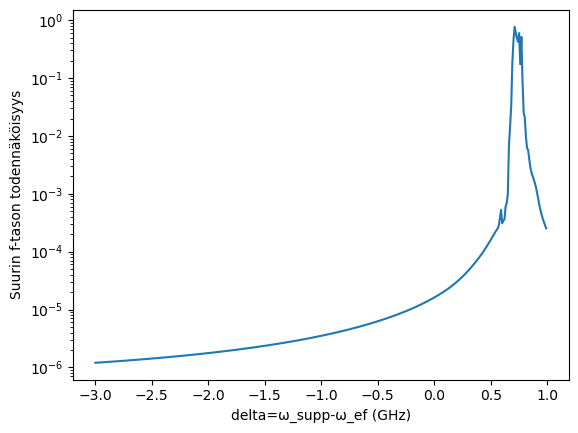

Amplitudi (GHz): 5.862378319577273
AC-stark siirtymä (GHz): -3.0
E-tason suurin todennäköisyys: 0.9998164206614689
F-tason suurin todennäköisyys: 2.034384190700204e-06
Pulssin pituus (ns): 248.5768581261148
Rabi-taajuus (fourier):  0.0021851671925186156


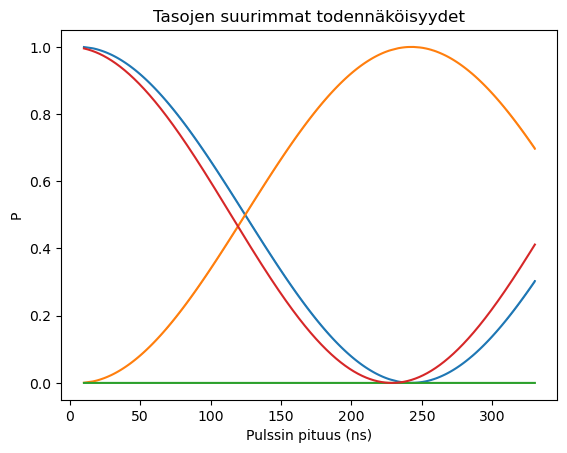

---------------------------------------------


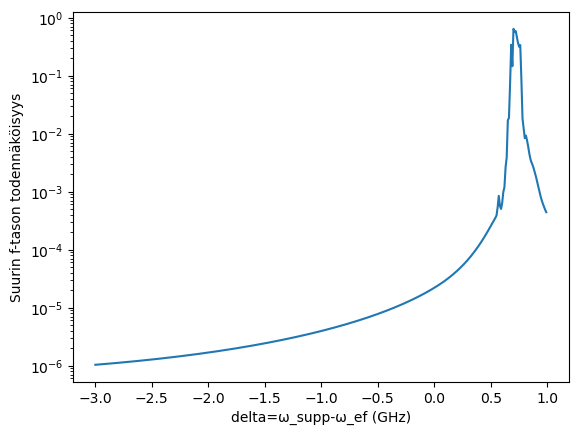

Amplitudi (GHz): 6.291660027189339
AC-stark siirtymä (GHz): -3.0
E-tason suurin todennäköisyys: 0.99900942027954
F-tason suurin todennäköisyys: 2.1875224999255523e-06
Pulssin pituus (ns): 200.3578165595798
Rabi-taajuus (fourier):  0.002458400625882118


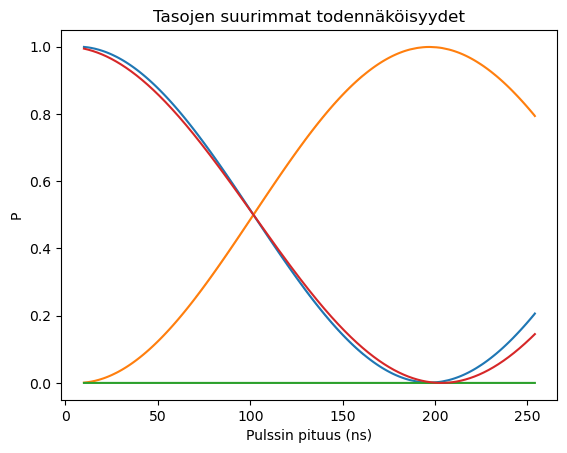

---------------------------------------------


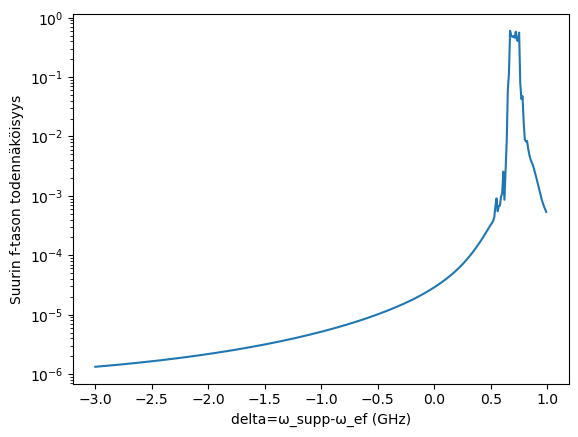

Amplitudi (GHz): 6.720941734801404
AC-stark siirtymä (GHz): -3.0
E-tason suurin todennäköisyys: 0.9988949005765597
F-tason suurin todennäköisyys: 2.5595179962026627e-06
Pulssin pituus (ns): 163.24149630460533
Rabi-taajuus (fourier):  0.003094154630618286


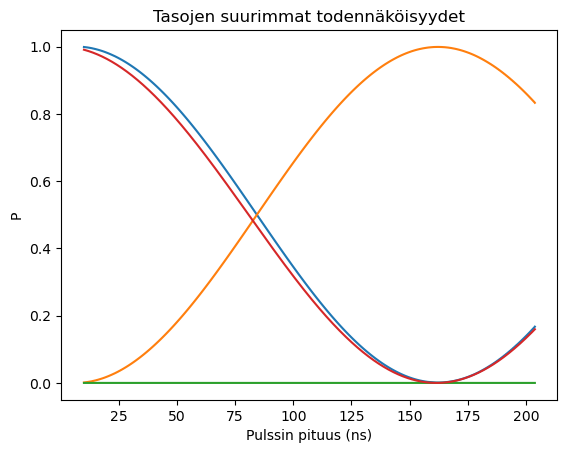

---------------------------------------------


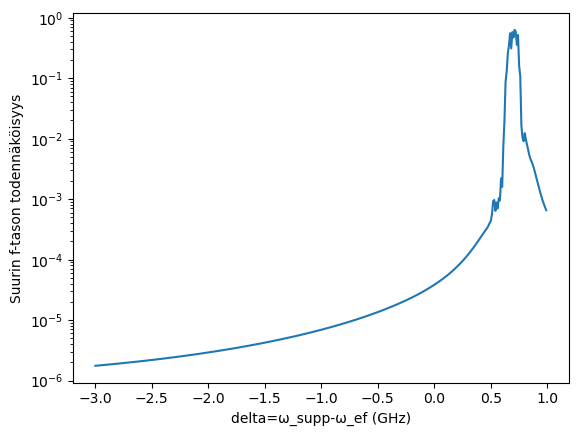

Amplitudi (GHz): 7.150223442413472
AC-stark siirtymä (GHz): -3.0
E-tason suurin todennäköisyys: 0.9994425822389165
F-tason suurin todennäköisyys: 2.9095931762019656e-06
Pulssin pituus (ns): 137.26336014916262
Rabi-taajuus (fourier):  0.0037933954609823974


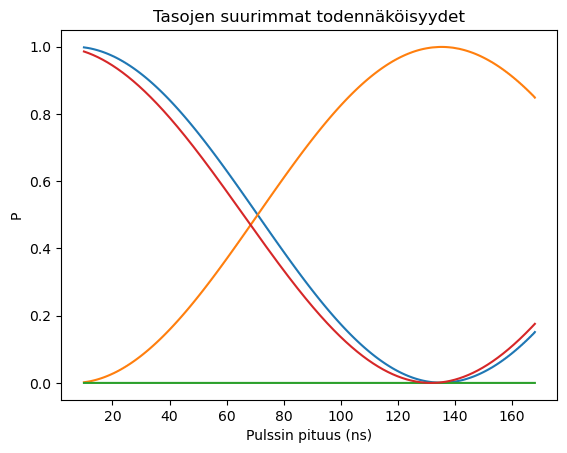

---------------------------------------------


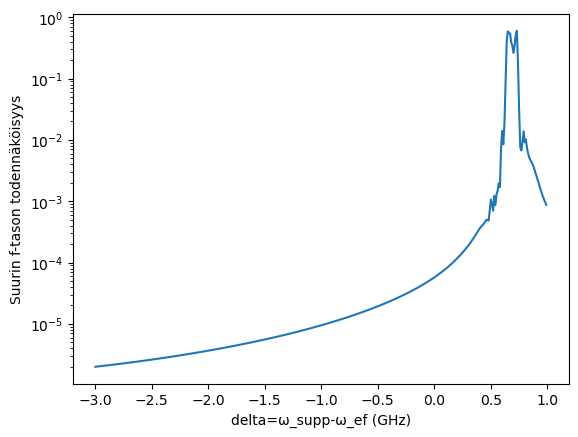

Amplitudi (GHz): 7.579505150025537
AC-stark siirtymä (GHz): -3.0
E-tason suurin todennäköisyys: 0.9986397557534001
F-tason suurin todennäköisyys: 2.8993046500257787e-06
Pulssin pituus (ns): 114.97118875844996
Rabi-taajuus (fourier):  0.004569028060243037


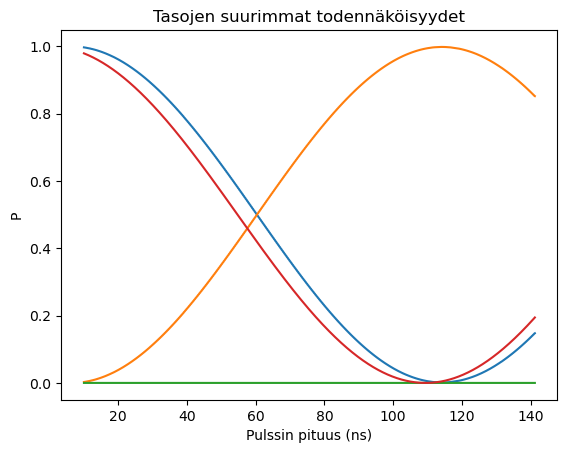

---------------------------------------------


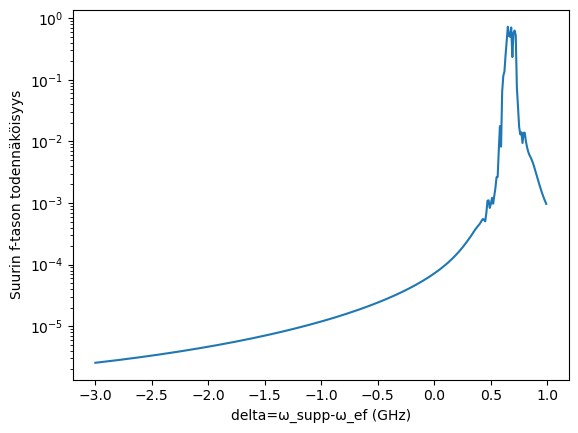

Amplitudi (GHz): 8.008786857637602
AC-stark siirtymä (GHz): -3.0
E-tason suurin todennäköisyys: 0.9981271589818753
F-tason suurin todennäköisyys: 3.2024561185011586e-06
Pulssin pituus (ns): 97.12308370128781
Rabi-taajuus (fourier):  0.00543411873215348


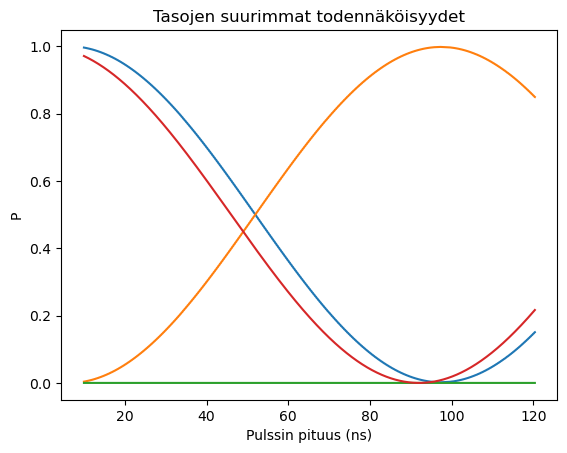

---------------------------------------------


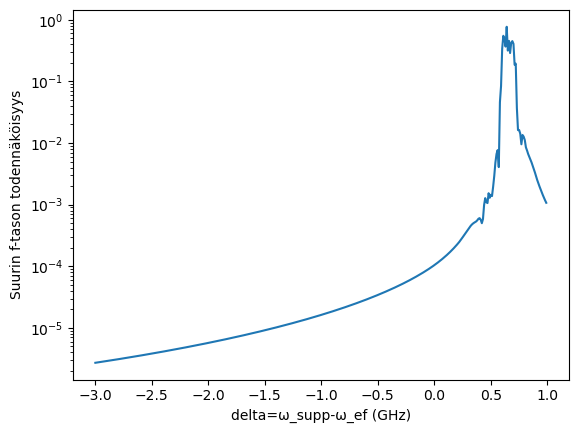

Amplitudi (GHz): 8.438068565249667
AC-stark siirtymä (GHz): -3.0
E-tason suurin todennäköisyys: 0.998091652132563
F-tason suurin todennäköisyys: 3.43414003802573e-06
Pulssin pituus (ns): 83.73611955305073
Rabi-taajuus (fourier):  0.006401783976256065


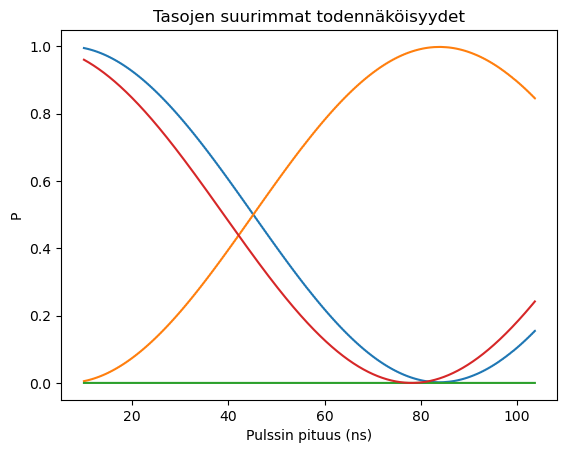

---------------------------------------------


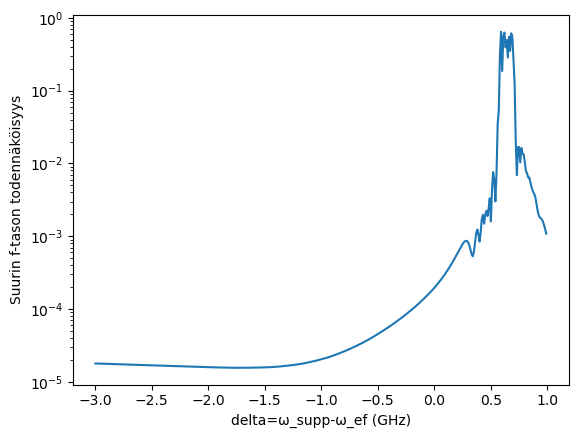

Amplitudi (GHz): 8.867350272861733
AC-stark siirtymä (GHz): -1.74
E-tason suurin todennäköisyys: 0.996009648756606
F-tason suurin todennäköisyys: 7.551068996815359e-05
Pulssin pituus (ns): 73.32256092736739
Rabi-taajuus (fourier):  0.0074850693848342


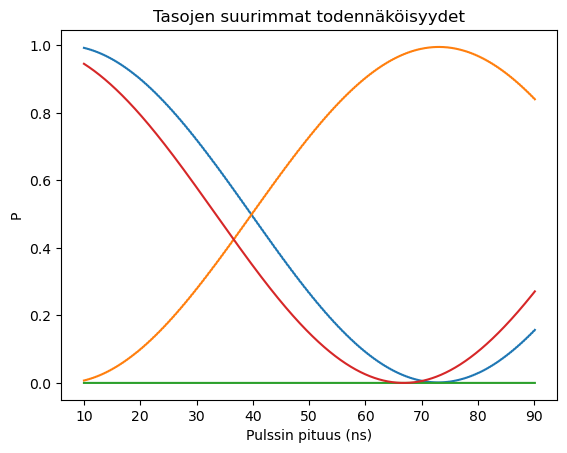

---------------------------------------------


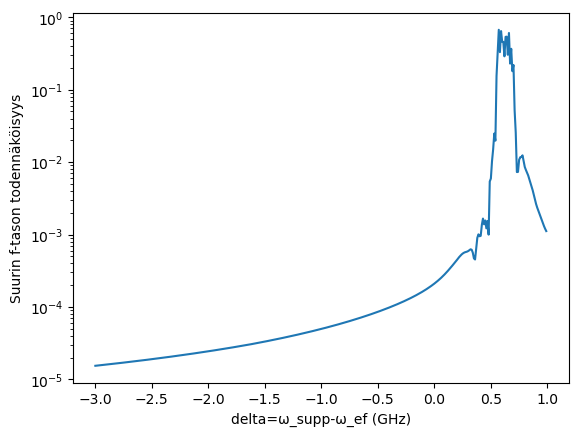

Amplitudi (GHz): 9.2966319804738
AC-stark siirtymä (GHz): -3.0
E-tason suurin todennäköisyys: 0.9956922483453906
F-tason suurin todennäköisyys: 1.6395951560063317e-05
Pulssin pituus (ns): 63.634637731236644
Rabi-taajuus (fourier):  0.008696625926199898


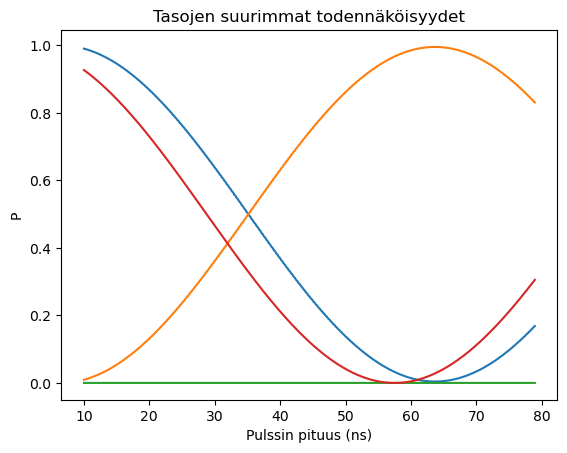

---------------------------------------------


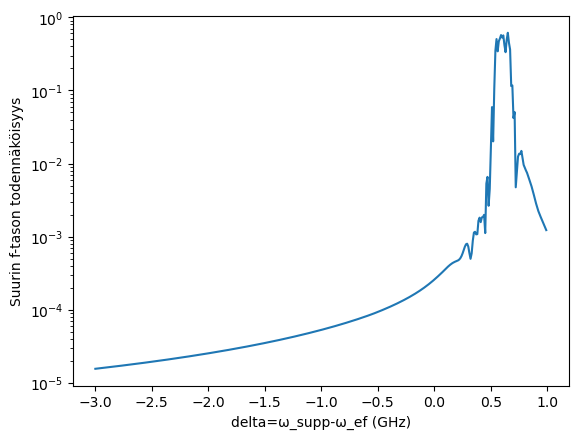

Amplitudi (GHz): 9.725913688085866
AC-stark siirtymä (GHz): -3.0
E-tason suurin todennäköisyys: 0.9929767849160828
F-tason suurin todennäköisyys: 1.6140722255904862e-05
Pulssin pituus (ns): 56.18241197365117
Rabi-taajuus (fourier):  0.010050212354223046


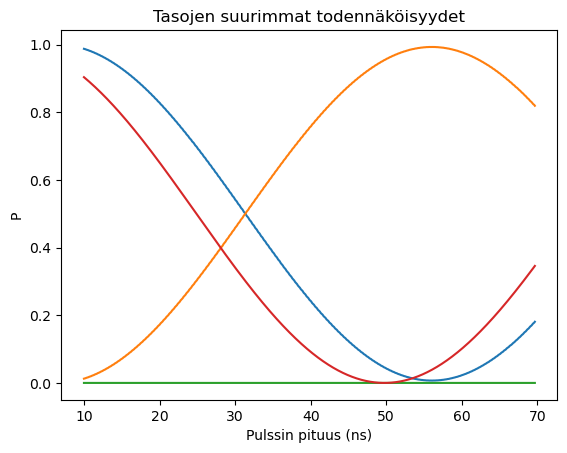

---------------------------------------------


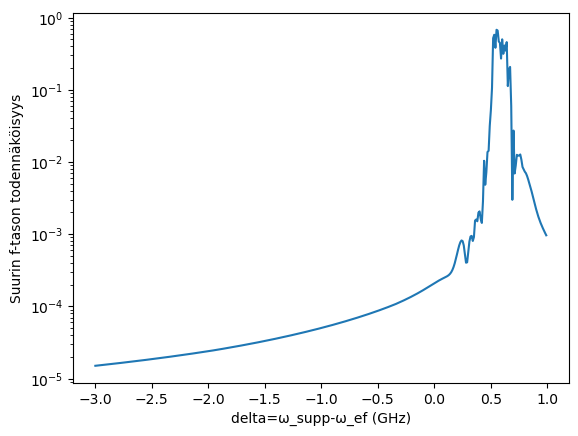

Amplitudi (GHz): 10.155195395697932
AC-stark siirtymä (GHz): -3.0
E-tason suurin todennäköisyys: 0.9902662812105771
F-tason suurin todennäköisyys: 1.7071950831187114e-05
Pulssin pituus (ns): 49.46094069328455
Rabi-taajuus (fourier):  0.01155844239159615


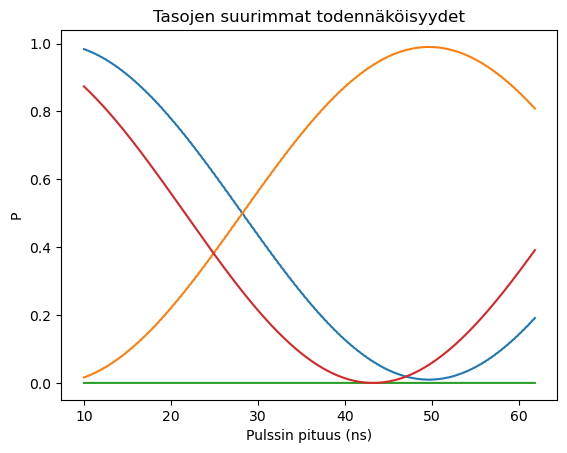

---------------------------------------------


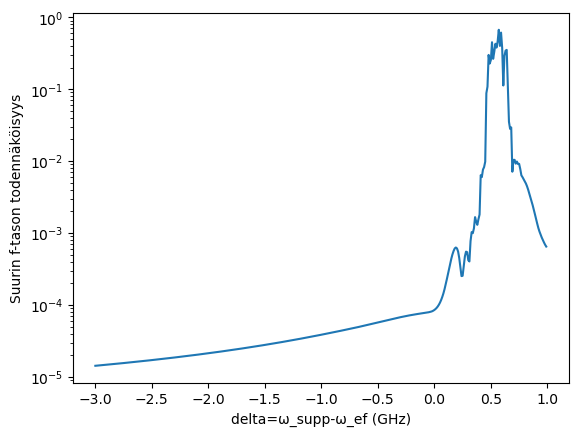

Amplitudi (GHz): 10.584477103309997
AC-stark siirtymä (GHz): -3.0
E-tason suurin todennäköisyys: 0.9837275989696957
F-tason suurin todennäköisyys: 2.0205468820407267e-05
Pulssin pituus (ns): 43.47482494440049
Rabi-taajuus (fourier):  0.013234642879198042


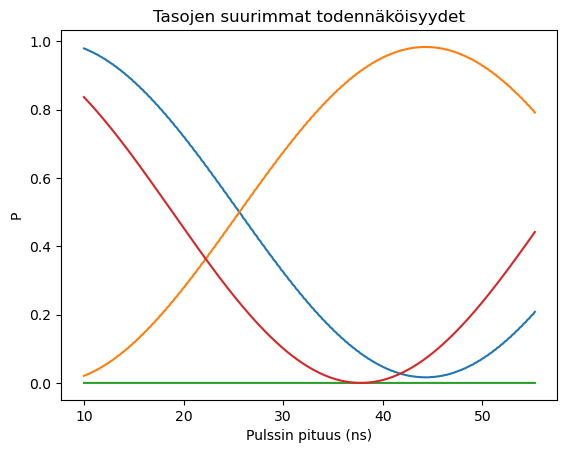

---------------------------------------------


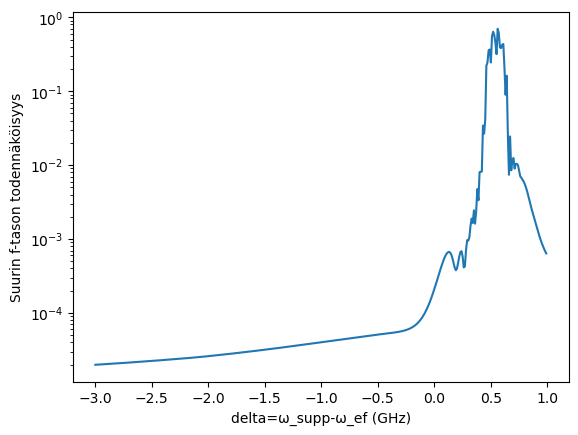

Amplitudi (GHz): 11.013758810922063
AC-stark siirtymä (GHz): -3.0
E-tason suurin todennäköisyys: 0.976192159281064
F-tason suurin todennäköisyys: 2.6394216791468934e-05
Pulssin pituus (ns): 39.75095040002637
Rabi-taajuus (fourier):  0.015090742425267357


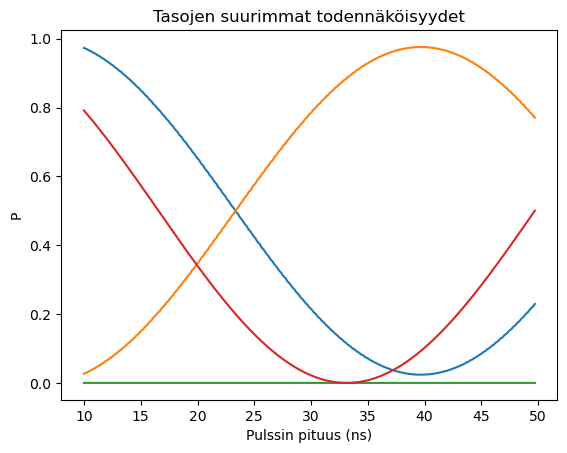

---------------------------------------------


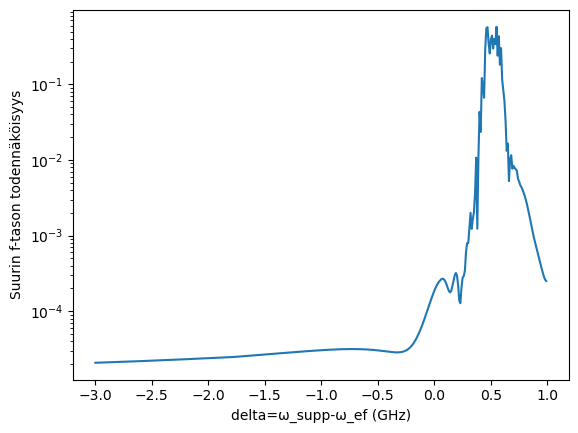

Amplitudi (GHz): 11.443040518534128
AC-stark siirtymä (GHz): -3.0
E-tason suurin todennäköisyys: 0.9337577939215718
F-tason suurin todennäköisyys: 3.9222017864691116e-05
Pulssin pituus (ns): 35.25478956766333
Rabi-taajuus (fourier):  0.017140570623014724


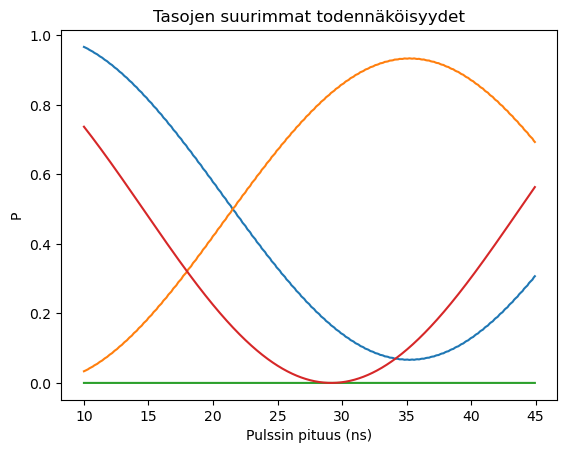

---------------------------------------------


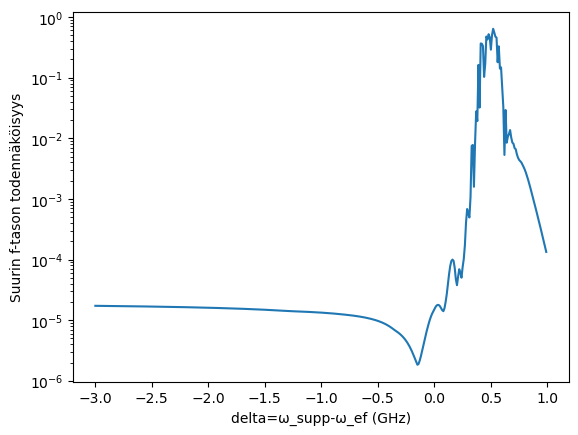

Amplitudi (GHz): 11.872322226146194
AC-stark siirtymä (GHz): -0.15
E-tason suurin todennäköisyys: 0.9958677957074209
F-tason suurin todennäköisyys: 0.00046460039222653973
Pulssin pituus (ns): 33.02380207685742
Rabi-taajuus (fourier):  0.019397088013746185


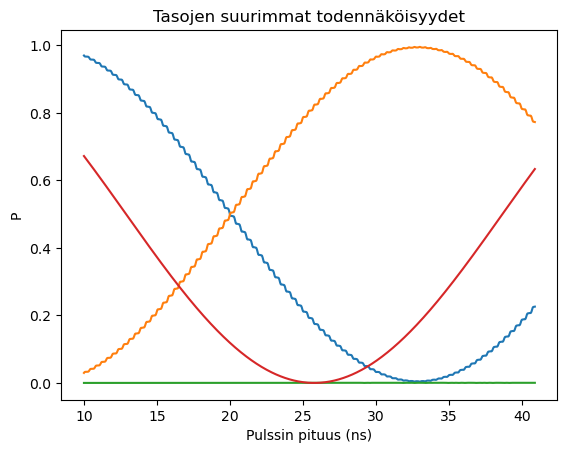

---------------------------------------------


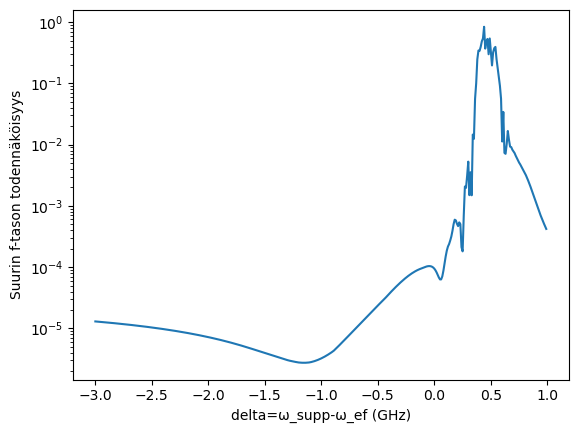

Amplitudi (GHz): 12.301603933758262
AC-stark siirtymä (GHz): -1.15
E-tason suurin todennäköisyys: 0.9469816685117978
F-tason suurin todennäköisyys: 9.066703415417304e-05
Pulssin pituus (ns): 29.2506950934083
Rabi-taajuus (fourier):  0.021875144400606384


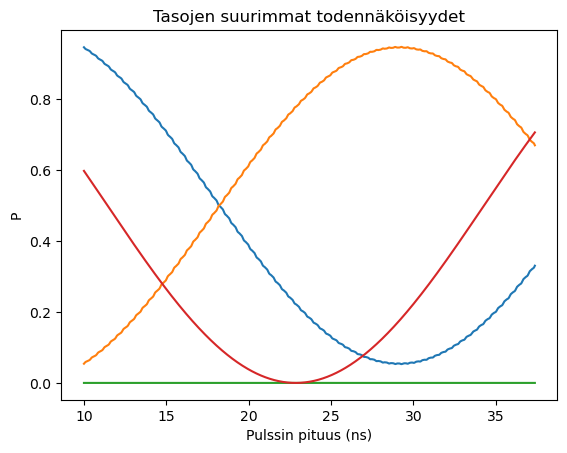

---------------------------------------------


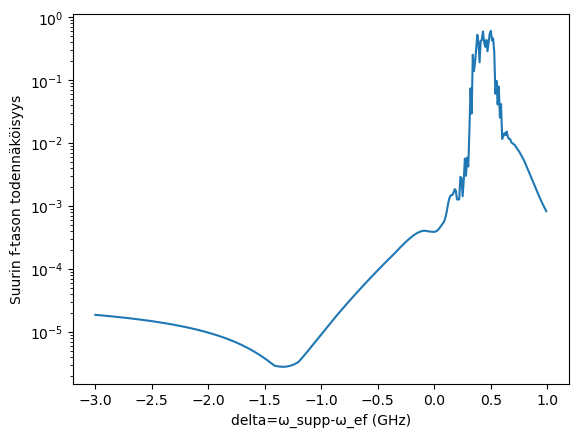

Amplitudi (GHz): 12.730885641370326
AC-stark siirtymä (GHz): -1.34
E-tason suurin todennäköisyys: 0.9254649938488888
F-tason suurin todennäköisyys: 0.00010581466715023787
Pulssin pituus (ns): 27.00031690245345
Rabi-taajuus (fourier):  0.02458306519131889


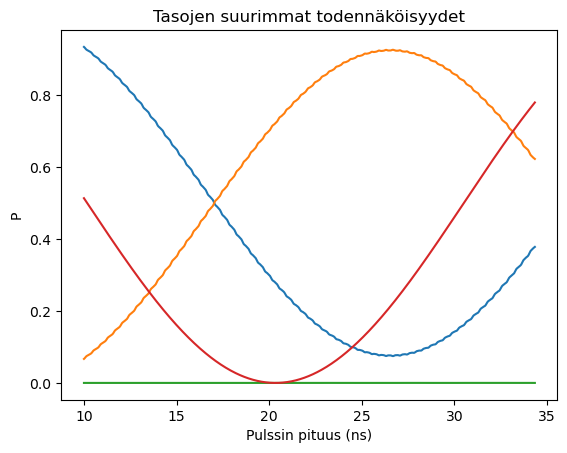

---------------------------------------------


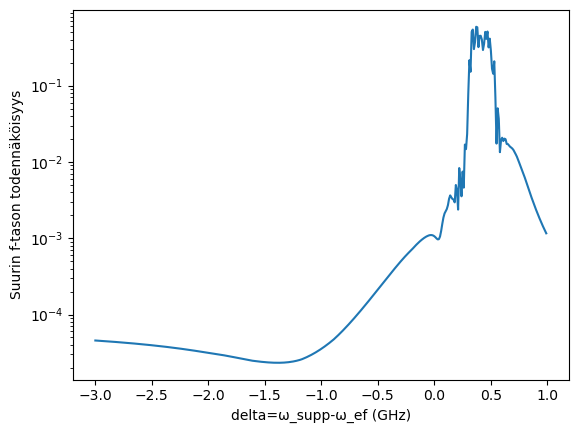

Amplitudi (GHz): 13.160167348982393
AC-stark siirtymä (GHz): -1.39
E-tason suurin todennäköisyys: 0.888736990415089
F-tason suurin todennäköisyys: 0.00014211135553021613
Pulssin pituus (ns): 23.96398559782557
Rabi-taajuus (fourier):  0.027538478070503275


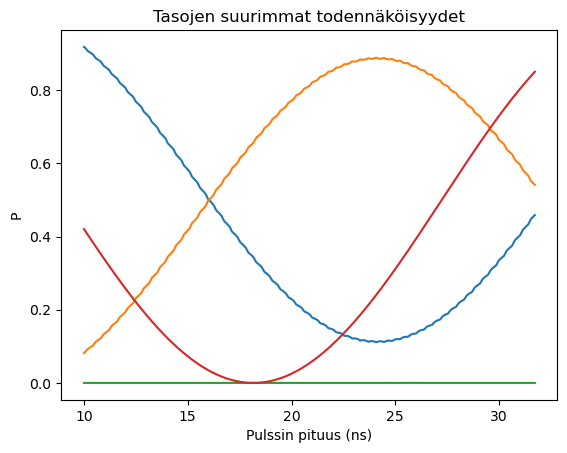

---------------------------------------------


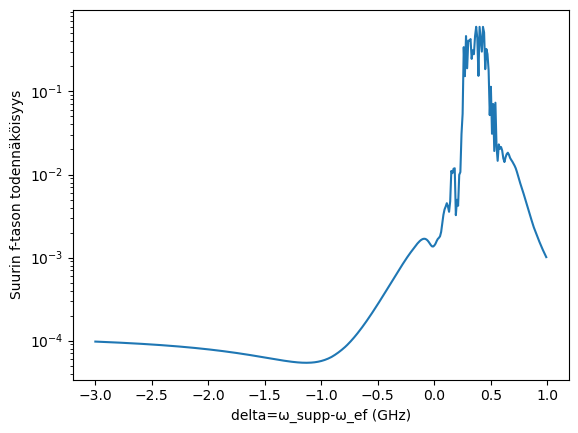

Amplitudi (GHz): 13.589449056594457
AC-stark siirtymä (GHz): -1.13
E-tason suurin todennäköisyys: 0.8686889738702779
F-tason suurin todennäköisyys: 0.00018663056654143531
Pulssin pituus (ns): 21.68436316549461
Rabi-taajuus (fourier):  0.03075504922386023


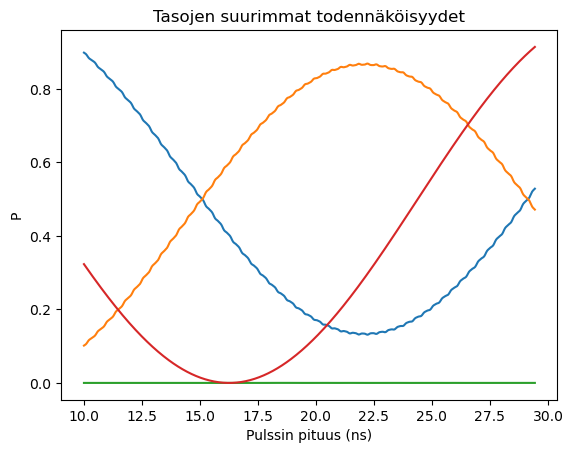

---------------------------------------------


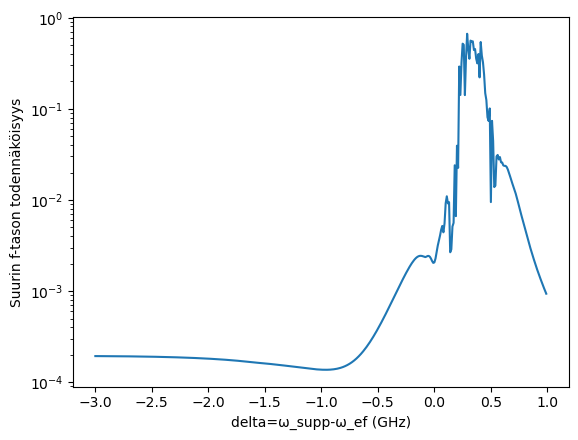

Amplitudi (GHz): 14.018730764206524
AC-stark siirtymä (GHz): -0.96
E-tason suurin todennäköisyys: 0.8476026782506991
F-tason suurin todennäköisyys: 0.00024611394379297125
Pulssin pituus (ns): 20.17099297739948
Rabi-taajuus (fourier):  0.03424366040216359


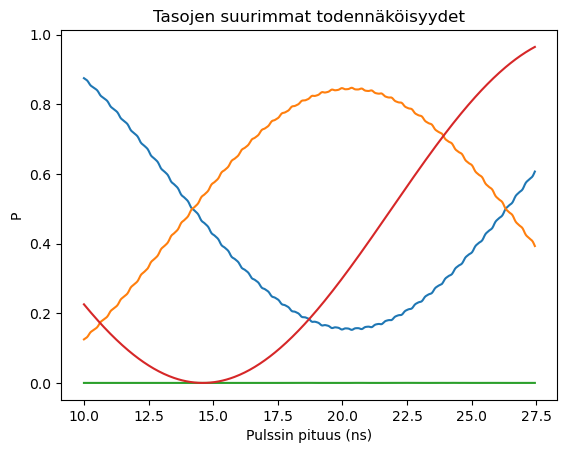

---------------------------------------------


In [7]:
deltas = [] #AC Stark siirtymät
pulse_lengths = [] #Pulssin pituudet
max_vals = [] #Suurimmat tasojen todennäköisyydet
rabis = [] #Rabi taajuudet (fouriermuunnoksesta)
data = [] #e-tason suurimmat todennäköisyydet amplitudin ja AC-stark siirtymän suhteen
A_vals = [] #Ajavan amplitudin arvot

#Määritellään rajat amplitudille sekä simulaatioiden määrä
min_range = 0.23
max_range = 0.55
N_data=20
d_data=(max_range-min_range)/(N_data-1)

for i in range (0,N_data):
    
    A = qubit.frequency*(min_range+i*d_data)
    A_vals.append(A)

    f_d_opt = qubit.frequency/3+list_AC_stark_vals[i] #Optimaalinen ajotaajuus

    f_rabi=2.875e-05*A**3 - 0.0003995*A**2 + 0.003097*A - 0.008257 #Arvaus Rabi-taajuudelle
    AC_stark=0 #Arvaus AC-stark siirtymälle

    params=find_params(f_d_opt, A, evolution_eigenbasis,f_rabi*10,AC_stark,[-300,100],100)

    deltas.append(params[0])
    pulse_lengths.append(params[1])
    max_vals.append(params[2])
    data.append(params[3])
    
    m=10

    vals = pulses.sim_3_part_pulses(f_d_opt,f_ef/3+deltas[-1],A,evolution_eigenbasis,dim,(f_rabi*10)/m,t_ramp=5,U_f=0,drag=True)

    print("Amplitudi (GHz):", A)
    print("AC-stark siirtymä (GHz):", deltas[-1])

    print("E-tason suurin todennäköisyys:", vals[0])
    print("F-tason suurin todennäköisyys:", vals[1])
    print("Verrokki:",params[2])


    print("Pulssin pituus (ns):", pulse_lengths[-1])

    g_vals=np.array([arr[0] for arr in vals[3]])
    e_vals=np.array([arr[1] for arr in vals[3]])
    f_vals=np.array([arr[2] for arr in vals[3]])

    g_vals_offset = g_vals-0.5 #Siirretään g-tason todennäköisyyksiä puolella alaspäin, dc-komponentin minimoinniksi
    fft_vals = np.fft.rfft(g_vals_offset) #Fourier-muunnos

    #Taajuusavaruus
    freqs = np.fft.rfftfreq(len(g_vals), d=vals[4][1]-vals[4][0]) 

    magnitude = np.abs(fft_vals) #Taajuuskomponentit
    magnitude[0] = 0 #Hylätään nollataajuus/vakiokomponentti

    frequency=freqs[np.argmax(magnitude)] #Suurin g-tason aikakehityksen taajuuskomponentti=Rabi-taajuus
    print("Rabi-taajuus (fourier): ",frequency)
    rabis.append(frequency)

    n_picked = int(len(vals[3])/m) #Plottausta varten käytetty pisteiden määrä
    
    plot_vals= 0.5*(1+np.cos(2*np.pi*frequency*vals[4][:n_picked])) #Sovite Rabi-taajuudella

    plt.figure()
    plt.plot(vals[4][:n_picked], g_vals[:n_picked])
    plt.plot(vals[4][:n_picked], e_vals[:n_picked])
    plt.plot(vals[4][:n_picked], f_vals[:n_picked])
    plt.plot(vals[4][:n_picked], plot_vals)
    plt.xlabel("Pulssin pituus (ns)")
    plt.ylabel("P")
    plt.title("Tasojen suurimmat todennäköisyydet")
    plt.show()

    print("---------------------------------------------")

[np.float64(5.862378319577273), np.float64(6.291660027189339), np.float64(6.720941734801404), np.float64(7.150223442413472), np.float64(7.579505150025537), np.float64(8.008786857637602), np.float64(8.438068565249667), np.float64(8.867350272861733), np.float64(9.2966319804738), np.float64(9.725913688085866), np.float64(10.155195395697932), np.float64(10.584477103309997), np.float64(11.013758810922063), np.float64(11.443040518534128), np.float64(11.872322226146194), np.float64(12.301603933758262), np.float64(12.730885641370326), np.float64(13.160167348982393), np.float64(13.589449056594457), np.float64(14.018730764206524)]


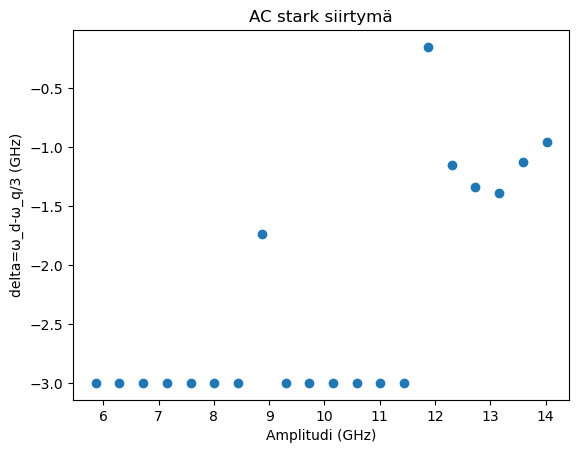

[-3.0, -3.0, -3.0, -3.0, -3.0, -3.0, -3.0, -1.74, -3.0, -3.0, -3.0, -3.0, -3.0, -3.0, -0.15, -1.15, -1.34, -1.39, -1.13, -0.96]


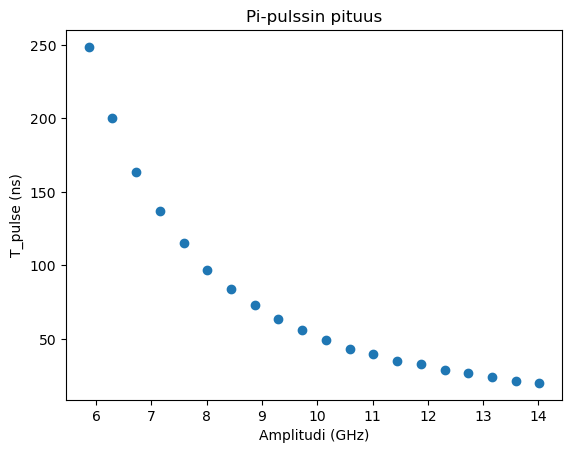

[np.float64(248.5768581261148), np.float64(200.3578165595798), np.float64(163.24149630460533), np.float64(137.26336014916262), np.float64(114.97118875844996), np.float64(97.12308370128781), np.float64(83.73611955305073), np.float64(73.32256092736739), np.float64(63.634637731236644), np.float64(56.18241197365117), np.float64(49.46094069328455), np.float64(43.47482494440049), np.float64(39.75095040002637), np.float64(35.25478956766333), np.float64(33.02380207685742), np.float64(29.2506950934083), np.float64(27.00031690245345), np.float64(23.96398559782557), np.float64(21.68436316549461), np.float64(20.17099297739948)]


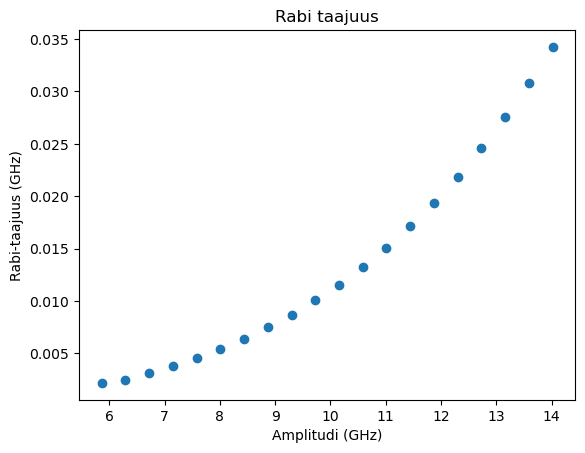

[np.float64(0.0021851671925186156), np.float64(0.002458400625882118), np.float64(0.003094154630618286), np.float64(0.0037933954609823974), np.float64(0.004569028060243037), np.float64(0.00543411873215348), np.float64(0.006401783976256065), np.float64(0.0074850693848342), np.float64(0.008696625926199898), np.float64(0.010050212354223046), np.float64(0.01155844239159615), np.float64(0.013234642879198042), np.float64(0.015090742425267357), np.float64(0.017140570623014724), np.float64(0.019397088013746185), np.float64(0.021875144400606384), np.float64(0.02458306519131889), np.float64(0.027538478070503275), np.float64(0.03075504922386023), np.float64(0.03424366040216359)]


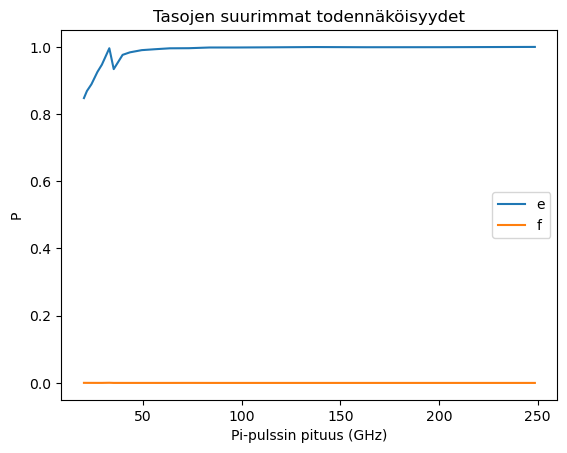

[np.float64(0.9998164206614689), np.float64(0.99900942027954), np.float64(0.9988949005765597), np.float64(0.9994425822389165), np.float64(0.9986397557534001), np.float64(0.9981271589818753), np.float64(0.998091652132563), np.float64(0.996009648756606), np.float64(0.9956922483453906), np.float64(0.9929767849160828), np.float64(0.9902662812105771), np.float64(0.9837275989696957), np.float64(0.976192159281064), np.float64(0.9337577939215718), np.float64(0.9958677957074209), np.float64(0.9469816685117978), np.float64(0.9254649938488888), np.float64(0.888736990415089), np.float64(0.8686889738702779), np.float64(0.8476026782506991)]
[np.float64(2.034384190700204e-06), np.float64(2.1875224999255523e-06), np.float64(2.5595179962026627e-06), np.float64(2.9095931762019656e-06), np.float64(2.8993046500257787e-06), np.float64(3.2024561185011586e-06), np.float64(3.43414003802573e-06), np.float64(7.551068996815359e-05), np.float64(1.6395951560063317e-05), np.float64(1.6140722255904862e-05), np.float

In [8]:
print(A_vals)

plt.figure()
plt.plot(A_vals, deltas, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("delta=ω_d-ω_q/3 (GHz)")
plt.title("AC stark siirtymä")
plt.show()
print(deltas)

plt.figure()
plt.plot(A_vals, pulse_lengths, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("T_pulse (ns)")
plt.title("Pi-pulssin pituus")
plt.show()
print(pulse_lengths)

plt.figure()
plt.plot(A_vals, rabis, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("Rabi-taajuus (GHz)")
plt.title("Rabi taajuus")
plt.show()
print(rabis)

e_vals=[arr[0] for arr in max_vals]
f_vals=[arr[1] for arr in max_vals]

plt.figure()
plt.semilogy(pulse_lengths, e_vals)
plt.semilogy(pulse_lengths, f_vals)
plt.legend(["e","f"])
plt.xlabel("Pi-pulssin pituus (GHz)")
plt.ylabel("P")
plt.title("Tasojen suurimmat todennäköisyydet")
plt.show()
print(e_vals)
print(f_vals)